In [1]:
# load the dishes table from the database
from sqlalchemy.orm import Session
from db.db_read import setup_database_connection
from secret import USER, PASSWORD, HOST, PORT
from db.db_write import Dish
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import re
import os
from spacy.matcher import PhraseMatcher
import spacy


engine, Session = setup_database_connection(USER, PASSWORD, HOST, PORT)

# query dishes table and transform to dataframe
def load_dishes_table():
    with Session() as session:
        dishes = session.query(Dish).all()
        data = [dish.__dict__ for dish in dishes]
        for item in data:
            item.pop('_sa_instance_state', None)  # Remove SQLAlchemy state info
        return pd.DataFrame(data)


df = load_dishes_table()

menu_lines = ["Angebot des Tages", "Auswahlgericht", "Auswahlgericht veget.", "Auswahlgericht vegan 2", "Angebot d. Tages veget.", "Tagesmenü vegan","Tagesmenü","mensaVital vegetarisch","Auswahlgericht 2"]
f_df = df[df['menuLine'].isin(menu_lines)]

f_df.meats.replace('NA', None, inplace=True)
f_df.icons.replace('NA', None, inplace=True)
f_df.menu.replace('NA', None, inplace=True)


# if "menu" is na, remove row
f_df = f_df.dropna(subset=['menu'])


Successfully connected to database


In [2]:
# build a function that adds the string "vegan" to the icons column if the string in the "menu" column contains "vegan"
def add_vegan(row, keywords=['vegan','pommes frites']):
    if pd.isna(row['icons']):
        for keyword in keywords:
            if keyword in row['menu'].lower():
                return 'vegan'
        return None
    else:
        return row['icons']

# count NA values in meats and icons columns
print(f_df.meats.isna().sum())
print(f_df.icons.isna().sum())

19
5


In [3]:
f_df['icons'] = f_df.apply(add_vegan, axis=1)
print(f_df.icons.isna().sum())

1


In [4]:
def merge_strings(row):
    meats = row['meats']
    icons = row['icons']
    
    # Clean up "Vegan, vegan" in icons
    if isinstance(icons, str):
        icons = icons.replace("Vegan, vegan", "vegan")

    if pd.isna(meats) and pd.isna(icons):
        return None
    elif pd.isna(meats):
        return icons
    elif pd.isna(icons):
        return meats
    else:
        meats_set = set(meats.split(', '))
        icons_set = set(icons.split(', '))
        merged_set = meats_set.union(icons_set)
        return ', '.join(merged_set)

f_df['merged_meats_icons'] = f_df.apply(merge_strings, axis=1)

f_df.merged_meats_icons.fillna("NA", inplace=True)


In [5]:
# show menu column where merged_meats_icons is NA
f_df

,menu,studentPrice,guestPrice,meats,allergens,menuDate,menuLine,id,location,pupilPrice,icons,additives,merged_meats_icons
0,"Pizza Tonno mit Thunfisch und Zweibeln oder, P...",6.50,6.5,None,"ML, Gl-a, Gl-b, Nu-c",2024-12-18,Angebot des Tages,1,Cafeteria Wilhelmstraße,6.5,None,11,NA
1,"Pasta hausgemacht-Papardelle mit, Wildsugo od...",6.50,6.5,W,"ML, Sf, Gl-a, ALK",2024-12-19,Angebot des Tages,2,Cafeteria Wilhelmstraße,6.5,W,4,W
2,Pasta Rustica,3.80,3.8,"S, R","Se, Sn, Gl-a",2024-12-17,Angebot des Tages,3,Cafeteria Morgenstelle,3.8,"S, R","2, 3, 4, 5","S, R"
3,Pommes frites,1.70,1.7,None,NA,2024-12-18,Angebot des Tages,4,Cafeteria Morgenstelle,1.7,vegan,9,vegan
4,Pommes frites,1.70,1.7,None,NA,2024-12-19,Angebot des Tages,5,Cafeteria Morgenstelle,1.7,vegan,9,vegan
5,"Nasi Goreng mit Mini Frühlingsrollen , Salat d...",3.90,8.2,None,"Se, So, Sn, Gl-a, Gl-c",2024-12-17,Auswahlgericht vegan 2,6,Cafeteria und Mensa Prinz Karl,8.2,V,2,V
6,"gebratene Tofuscheibe , Zucchinigemüse, Dinkel...",-1.00,-1.0,None,"So, Gl-a",2024-12-18,Auswahlgericht vegan 2,7,Cafeteria und Mensa Prinz Karl,-1.0,"Vegan, vegan",1,vegan
7,"Tortellini mit Gemüsefüllung , Kräutersauce, S...",-1.00,-1.0,None,"So, Gl-a",2024-12-19,Auswahlgericht vegan 2,8,Cafeteria und Mensa Prinz Karl,-1.0,V,NA,V
8,"Sojageschnetzeltes , Beilage nach Wahl, kleine...",4.20,8.5,None,"Ei, So, Sn",2024-12-17,Auswahlgericht veget.,9,Cafeteria und Mensa Prinz Karl,8.5,vegan,NA,vegan
9,"Gemüsebällchen , Beilage nach Wahl, kleiner Be...",4.20,8.5,None,"Ei, Se, Sn, Gl-a",2024-12-18,Auswahlgericht veget.,10,Cafeteria und Mensa Prinz Karl,8.5,V,NA,V


In [6]:
# Define the folder path
folder_path = 'C:/Users/danie/OneDrive/Dokumente/mensa_data_meyer'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and concatenate all CSV files into one DataFrame
all_dataframes = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
combined_df = pd.concat(all_dataframes, ignore_index=True)

combined_df = combined_df[combined_df['category'].isin(menu_lines)]
combined_df.meal.replace('NA', None, inplace=True)
combined_df = combined_df.dropna(subset=['meal'])

# Function to clean text
def preprocess_text(text):
    text = re.sub(r"\[.*?\]", "", text).strip()
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-zäöüß\s]", "", text)
    return text.strip()


# Load German spaCy model
nlp = spacy.load("de_core_news_sm")

def extract_nouns(text, nlp):
    doc = nlp(text)
    nouns = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]
    return nouns


# Predefined ingredient list
ingredient_list = ['pommes', 'schinken','kroketten','reis','couscous','käse','soja','saiten','maultaschen','tofu','ravioli','lachs','piccata','spätzle','schupfnudeln','weißkraut','spargel','rotkohl','linsen','erbsen','broccoli','nudeln','kartoffeln','pilze', 'karotten', 'salat', 'curry','käsesahnesauce', 'bolognese', 'remoulade', 'röstzwiebeln','tomaten', 'tzatziki', 'braten','rahmsauce','rahmsauce','hollandaise', 'kokos', 'kokossauce','süß-sauer', 'barbecue sauce','barbecue','ajvar', 'kräuter']

patterns = [nlp.make_doc(ingredient) for ingredient in ingredient_list]

# Initialize PhraseMatcher
matcher = PhraseMatcher(nlp.vocab)
matcher.add("INGREDIENTS", patterns)


# Match ingredients
def extract_ingredients(text, nlp, matcher):
    doc = nlp(preprocess_text(text))
    matches = matcher(doc)
    return [doc[start:end].text for match_id, start, end in matches]



# Apply ingredient extraction
combined_df["ingredients"] = combined_df["meal"].apply(lambda x: extract_ingredients(x, nlp, matcher))


In [7]:

combined_df


,category,meal,date,day,student_price,allergens,additives,guest_price,employee_price,price,ingredients
0,Tagesmenü,Hähnchenbrustfilet natur [G] - Kokos-Currysauc...,01.02.2023,Mittwoch,"3,10€",Allergene: (So) Soja(ML) Milch / Laktose(Gl-a)...,Zusatzstoffe: (1) Farbstoff,"6,75€","4,05€",NaN,[]
2,Auswahlgericht,Hausgemachter - Spicy Crunchy-Chickenburger - ...,01.02.2023,Mittwoch,"3,90€",Allergene: (Ei) Eier(Se) Sellerie(ML) Milch / ...,Zusatzstoffe: (1) Farbstoff,"8,10€","5,40€",NaN,[salat]
7,Tagesmenü,Paniertes Schweineschnitzel [S] - Rahmsauce - ...,01.02.2024,Donnerstag,"3,10€",Allergene: (Ei) Eier(ML) Milch / Laktose,Zusatzstoffe: -,"6,75€","4,05€",NaN,"[rahmsauce, pommes]"
8,Tagesmenü vegan,Gemüse-Knusperbagel [V] - Vollkornreis - Erbse...,01.02.2024,Donnerstag,"3,10€",Allergene: (Se) Sellerie(Gl-a) Weizen(Gl-e) Di...,Zusatzstoffe: -,"6,75€","4,05€",NaN,[]
9,Auswahlgericht,bunter Gulaschtopf Pustza [S] - mit einer Beil...,01.02.2024,Donnerstag,"3,40€",Allergene: -,Zusatzstoffe: -,"7,60€","4,90€",NaN,[]
...,...,...,...,...,...,...,...,...,...,...,...
3051,Angebot d. Tages veget.,Vegetarische Krautschupfnudeln [V],31.10.2022,Montag,"2,65€",Allergene: (Ei) Eier(Gl-a) Weizen,Zusatzstoffe: -,"6,30€","3,60€",NaN,[]
3052,Auswahlgericht,Schwabenteller [S/R] - Käsespätzle,31.10.2022,Montag,"3,10€",Allergene: (Ei) Eier(Se) Sellerie(ML) Milch / ...,Zusatzstoffe: -,"7,30€","4,60€",NaN,[]
3057,Tagesmenü,Gebratener Schweinerücken [S] - Pilzrahmsauce ...,31.10.2023,Dienstag,"3,10€",Allergene: (Ei) Eier(Sn) Senf(ML) Milch / Lakt...,Zusatzstoffe: (1) Farbstoff(4) Antioxidationsm...,"6,75€","4,05€",NaN,[spätzle]
3058,Tagesmenü vegan,Pfannengyros Soja [V] - Tzatziki - Pommes frit...,31.10.2023,Dienstag,"3,10€",Allergene: (Se) Sellerie(So) Soja(Sn) Senf(Sf)...,Zusatzstoffe: (1) Farbstoff(4) Antioxidationsm...,"6,75€","4,05€",NaN,"[soja, tzatziki, pommes, weißkraut]"


In [8]:
combined_df["meal_clean"]= combined_df["meal"].apply(lambda x: preprocess_text(x))

combined_df["ingredients"]= combined_df["meal_clean"].apply(lambda x: extract_nouns(x, nlp))
combined_df

,category,meal,date,day,student_price,allergens,additives,guest_price,employee_price,price,ingredients,meal_clean
0,Tagesmenü,Hähnchenbrustfilet natur [G] - Kokos-Currysauc...,01.02.2023,Mittwoch,"3,10€",Allergene: (So) Soja(ML) Milch / Laktose(Gl-a)...,Zusatzstoffe: (1) Farbstoff,"6,75€","4,05€",NaN,"[hähnchenbrustfilet, natur, kokoscurrysauce, d...",hähnchenbrustfilet natur kokoscurrysauce du...
2,Auswahlgericht,Hausgemachter - Spicy Crunchy-Chickenburger - ...,01.02.2023,Mittwoch,"3,90€",Allergene: (Ei) Eier(Se) Sellerie(ML) Milch / ...,Zusatzstoffe: (1) Farbstoff,"8,10€","5,40€",NaN,"[spicy, selbstgemachter, burgerdip, salat, kar...",hausgemachter spicy crunchychickenburger sel...
7,Tagesmenü,Paniertes Schweineschnitzel [S] - Rahmsauce - ...,01.02.2024,Donnerstag,"3,10€",Allergene: (Ei) Eier(ML) Milch / Laktose,Zusatzstoffe: -,"6,75€","4,05€",NaN,"[rahmsauce, blattsalat]",paniertes schweineschnitzel rahmsauce pomme...
8,Tagesmenü vegan,Gemüse-Knusperbagel [V] - Vollkornreis - Erbse...,01.02.2024,Donnerstag,"3,10€",Allergene: (Se) Sellerie(Gl-a) Weizen(Gl-e) Di...,Zusatzstoffe: -,"6,75€","4,05€",NaN,"[gemüseknusperbagel, vollkornreis, erbsengemüs...",gemüseknusperbagel vollkornreis erbsengemüs...
9,Auswahlgericht,bunter Gulaschtopf Pustza [S] - mit einer Beil...,01.02.2024,Donnerstag,"3,40€",Allergene: -,Zusatzstoffe: -,"7,60€","4,90€",NaN,"[gulaschtopf, pustza, beilage, wahl]",bunter gulaschtopf pustza mit einer beilage ...
...,...,...,...,...,...,...,...,...,...,...,...,...
3051,Angebot d. Tages veget.,Vegetarische Krautschupfnudeln [V],31.10.2022,Montag,"2,65€",Allergene: (Ei) Eier(Gl-a) Weizen,Zusatzstoffe: -,"6,30€","3,60€",NaN,[],vegetarische krautschupfnudeln
3052,Auswahlgericht,Schwabenteller [S/R] - Käsespätzle,31.10.2022,Montag,"3,10€",Allergene: (Ei) Eier(Se) Sellerie(ML) Milch / ...,Zusatzstoffe: -,"7,30€","4,60€",NaN,[schwabenteller],schwabenteller käsespätzle
3057,Tagesmenü,Gebratener Schweinerücken [S] - Pilzrahmsauce ...,31.10.2023,Dienstag,"3,10€",Allergene: (Ei) Eier(Sn) Senf(ML) Milch / Lakt...,Zusatzstoffe: (1) Farbstoff(4) Antioxidationsm...,"6,75€","4,05€",NaN,"[gebratener, pilzrahmsauce, spätzle, blattsalat]",gebratener schweinerücken pilzrahmsauce spä...
3058,Tagesmenü vegan,Pfannengyros Soja [V] - Tzatziki - Pommes frit...,31.10.2023,Dienstag,"3,10€",Allergene: (Se) Sellerie(So) Soja(Sn) Senf(Sf)...,Zusatzstoffe: (1) Farbstoff(4) Antioxidationsm...,"6,75€","4,05€",NaN,"[pfannengyros, soja]",pfannengyros soja tzatziki pommes frites w...


In [9]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Define stop words
stop_words = set(stopwords.words('german'))  # Replace 'german' with your language of choice

# Function to remove stop words
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

combined_df["meal_clean_spw"] = combined_df["meal_clean"].apply(remove_stopwords)

# Extract unique words
def get_unique_words(column):
    # Split all strings into words and flatten the list
    all_words = " ".join(column).split()
    # Get unique words
    unique_words = list(set(all_words))
    return unique_words

# Apply to the DataFrame column
unique_words_list = get_unique_words(combined_df['meal_clean_spw'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Sort words by length
sorted_words = sorted(unique_words_list, key=len)
sorted_words

['m',
 'g',
 's',
 'ei',
 'al',
 'de',
 'dim',
 'gla',
 'ial',
 'dip',
 'con',
 'soß',
 'sin',
 'shi',
 'and',
 'bio',
 'art',
 'huhn',
 'soße',
 'hong',
 'nasi',
 'zwei',
 'kong',
 'asia',
 'piri',
 'tofu',
 'rahm',
 'obst',
 'cous',
 'bami',
 'soja',
 'sfsn',
 'omas',
 'wahl',
 'mini',
 'fono',
 'bleu',
 'cafe',
 'orly',
 'paar',
 'reis',
 'käse',
 'wrap',
 'zimt',
 'mais',
 'rote',
 'kokos',
 'sauce',
 'forno',
 'gyros',
 'sesam',
 'mensa',
 'chili',
 'statt',
 'ghana',
 'curry',
 'style',
 'ajvar',
 'wurst',
 'glaei',
 'daher',
 'äpfel',
 'honig',
 'spicy',
 'china',
 'chips',
 'fisch',
 'ayvar',
 'mango',
 'brühe',
 'veget',
 'penne',
 'beete',
 'stück',
 'lauch',
 'tatar',
 'süßem',
 'roten',
 'paris',
 'pilze',
 'bunte',
 'speck',
 'carne',
 'nudel',
 'grüne',
 'salsa',
 'puten',
 'lollo',
 'wings',
 'natur',
 'gurke',
 'pasta',
 'rosso',
 'eigla',
 'hawai',
 'jäger',
 'apfel',
 'vegan',
 'salat',
 'vorrat',
 'saison',
 'erbsen',
 'madras',
 'saiten',
 'dienst',
 'spinat',
 'ruc

In [11]:
len(unique_words_list)

923

In [12]:
f_df

,menu,studentPrice,guestPrice,meats,allergens,menuDate,menuLine,id,location,pupilPrice,icons,additives,merged_meats_icons
0,"Pizza Tonno mit Thunfisch und Zweibeln oder, P...",6.50,6.5,None,"ML, Gl-a, Gl-b, Nu-c",2024-12-18,Angebot des Tages,1,Cafeteria Wilhelmstraße,6.5,None,11,NA
1,"Pasta hausgemacht-Papardelle mit, Wildsugo od...",6.50,6.5,W,"ML, Sf, Gl-a, ALK",2024-12-19,Angebot des Tages,2,Cafeteria Wilhelmstraße,6.5,W,4,W
2,Pasta Rustica,3.80,3.8,"S, R","Se, Sn, Gl-a",2024-12-17,Angebot des Tages,3,Cafeteria Morgenstelle,3.8,"S, R","2, 3, 4, 5","S, R"
3,Pommes frites,1.70,1.7,None,NA,2024-12-18,Angebot des Tages,4,Cafeteria Morgenstelle,1.7,vegan,9,vegan
4,Pommes frites,1.70,1.7,None,NA,2024-12-19,Angebot des Tages,5,Cafeteria Morgenstelle,1.7,vegan,9,vegan
5,"Nasi Goreng mit Mini Frühlingsrollen , Salat d...",3.90,8.2,None,"Se, So, Sn, Gl-a, Gl-c",2024-12-17,Auswahlgericht vegan 2,6,Cafeteria und Mensa Prinz Karl,8.2,V,2,V
6,"gebratene Tofuscheibe , Zucchinigemüse, Dinkel...",-1.00,-1.0,None,"So, Gl-a",2024-12-18,Auswahlgericht vegan 2,7,Cafeteria und Mensa Prinz Karl,-1.0,"Vegan, vegan",1,vegan
7,"Tortellini mit Gemüsefüllung , Kräutersauce, S...",-1.00,-1.0,None,"So, Gl-a",2024-12-19,Auswahlgericht vegan 2,8,Cafeteria und Mensa Prinz Karl,-1.0,V,NA,V
8,"Sojageschnetzeltes , Beilage nach Wahl, kleine...",4.20,8.5,None,"Ei, So, Sn",2024-12-17,Auswahlgericht veget.,9,Cafeteria und Mensa Prinz Karl,8.5,vegan,NA,vegan
9,"Gemüsebällchen , Beilage nach Wahl, kleiner Be...",4.20,8.5,None,"Ei, Se, Sn, Gl-a",2024-12-18,Auswahlgericht veget.,10,Cafeteria und Mensa Prinz Karl,8.5,V,NA,V


In [109]:
from openai import OpenAI
OPENAI_KEY = "***REMOVED_OPENAI_KEY***"
os.environ["OPENAI_API_KEY"] = OPENAI_KEY
client = OpenAI()

# Sentence-BERT example for German
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Function to clean text
def preprocess_text(text):
    text = re.sub(r"\[.*?\]", "", text).strip() # remove special characters
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-zäöüß\s]", "", text)
    text = text.replace("beilage", "").replace("wahl","").replace("mischsalat","").replace("blattsalat","").replace("bunter","")
    text = " ".join(text.split())

    # remove stopwords
    stop_words = set(stopwords.words('german'))  # Replace 'german' with your language of choice
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    text = " ".join(filtered_words)

    return text.strip()

def ingredient_extraction(df,column):

    ingredient_list = []  
    tokens_list = []
        
    for menu in df[column]:
        
        # Handle non-string or empty entries in the 'menu' column
        if not isinstance(menu, str) or not menu.strip():
            ingredient_list.append("")
            tokens_list.append(0)
            continue

        cleaned_text = preprocess_text(menu)
        
        # Create prompt to get dish ingredients
        messages = [
            {"role": "system", "content": (
                "Extract the ingredients from the following dish description. Only consider ingredients that are mentioned in the string. All ingredients should be nouns and in German. Provide the ingredients as a list separated by commas."
            )},
            {"role": "user", "content": (
                f"{cleaned_text}"
            )}
        ]
    
        # Send request using new `openai.ChatCompletion` interface
        completion = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages,
            max_tokens=200,
            temperature=0.2
        )
    
        # Extract ingredients and tokens used
        result = completion.choices[0].message.content.strip().split("\n")
        ingredients = result[0].strip() if len(result) > 0 else ""
        tokens_used = completion.usage.total_tokens
        
        # Append to lists
        ingredient_list.append(ingredients)
        tokens_list.append(tokens_used)
    
    # Add columns to DataFrame
    df['ingredients'] = ingredient_list
    df['tokens_used'] = tokens_list
        
    return df



def embedding_extraction(df,column):


    gpt_embedding_list = []  
    bert_embedding_list = []

    for menu in df[column]:
        
        # Handle non-string or empty entries in the 'menu' column
        if not isinstance(menu, str) or not menu.strip():
            ingredient_list.append("")
            continue
        
        cleaned_text = preprocess_text(menu)
    
        # get embedding for each meal
        response = client.embeddings.create(
        input=f"{cleaned_text}",
        model="text-embedding-3-small"
        )

        gpt_embedding_list.append(response.data[0].embedding)
        bert_embedding_list.append(model.encode(cleaned_text))
    
    
    # Add columns to DataFrame
    df['gpt_embedding'] = gpt_embedding_list
    df['bert_embedding'] = bert_embedding_list
        
    return df

# Example
#embedding_extraction(f_df,"menu")



In [110]:
# Cluster dish embeddings

# Define the folder path
folder_path = 'C:/Users/danie/OneDrive/Dokumente/mensa_data_meyer'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and concatenate all CSV files into one DataFrame
all_dataframes = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
combined_df = pd.concat(all_dataframes, ignore_index=True)

combined_df = combined_df[combined_df['category'].isin(menu_lines)]
combined_df.meal.replace('NA', None, inplace=True)
combined_df = combined_df.dropna(subset=['meal'])

#df = embedding_extraction(combined_df,"meal")
#df

In [111]:
# Convert the 'embedding' column to a matrix
import numpy as np
df = df.drop_duplicates(subset=['meal'])

embedding_matrix = np.vstack(df['bert_embedding'].values)
embedding_matrix.shape

df["meal_clean"]= df["meal"].apply(lambda x: preprocess_text(x))
df["bert_embedding"] = df["meal_clean"].apply(lambda x: model.encode(x))


In [124]:
from sklearn.cluster import KMeans
import numpy as np
import random
from sklearn.metrics import pairwise_distances_argmin_min

# Convert the list of embeddings into a 2D array
dish_names = df['meal_clean'].values

# Cluster the dish embeddings into k clusters
k = 6  # Choose the number of clusters
kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42).fit(embedding_matrix)


# Find the 10 menu names closest to the cluster centroids
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, embedding_matrix)
closest_dishes = [dish_names[idx] for idx in closest]

# Create a dictionary to store dish names for each cluster
clustered_dishes = {i: [] for i in range(k)}
for idx, label in enumerate(kmeans.labels_):
    clustered_dishes[label].append(dish_names[idx])

# Print the 10 menu names for each cluster
for cluster in range(k):
    print(f"Cluster {cluster}:")
    random_dishes = random.sample(clustered_dishes[cluster], min(10, len(clustered_dishes[cluster])))
    for dish in random_dishes:
        print(dish)
    print("\n")


Cluster 0:
hähnchenbrustfilet natur provenciale pommes dauphine ratatouillegemüse
chinesische glasnudeln gemüse tofu
mediterrane gnocchigemüsepfanne obst
wrap feurige drache gefüllt chili con carne soja bohnenpaprika salatgarnitur hausgemachter dip
geflügelragout paprikarahm reis balkangemüse
hähnchenbrustfilet natur pfefferrahmsauce kaisergemüse spätzle
ravioli frischkäsefüllung salbeibutter gebraten gemüse
pikantes asiatisches rindfleischgemüse curry
semmelknödel champignonragout kaisergemüse
chinaschnitte sauce süßsauer curryreis erbsengemüse


Cluster 1:
schweinebraten rahmsauce
gulaschtopf pustza
seelachs kartoffelpanade
hähnchenbruststreifen paprikarahmsoße
schweinebraten cevapcici pfefferrahmsauce ratatouillegemüse
gebackener gemüsestrudel
kartoffeltaschen ratatouillegemüsesauce
hähnchenbrustfilet tomatemozzarella überbacken
cevapcici chilidip
hähnchengulasch jäger art


Cluster 2:
schwäbische maultaschen zwiebelsauce kartoffelsalat
hausgemachter schwäbischer sauerbraten kartoff

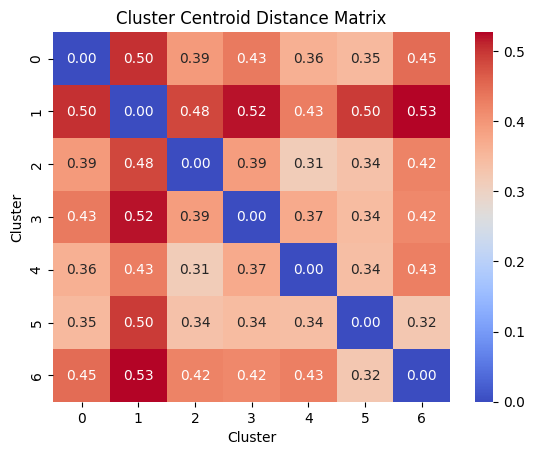

In [123]:
from sklearn.metrics.pairwise import euclidean_distances

# Get cluster centers
centroids = kmeans.cluster_centers_

# Compute pairwise distances between all centroids
distances = euclidean_distances(centroids, centroids)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of distances
sns.heatmap(distances, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Centroid Distance Matrix")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()


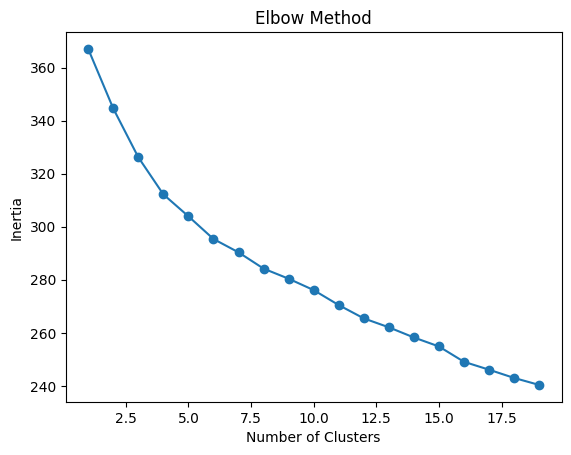

In [114]:
import matplotlib.pyplot as plt

# Compute inertia (sum of squared distances to cluster centers) for various k
inertia = []
k_values = range(1, 20)
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42).fit(embedding_matrix)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

(19, 512)

In [85]:
from sklearn.cluster import DBSCAN

df2 = df[['meal','category']].copy()
# Apply DBSCAN clustering
eps = 0.1  # Maximum distance for points to be in the same cluster
min_samples = 5 # Minimum number of points to form a cluster
dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(embedding_matrix)

# Extract cluster labels
df2["db_scan_labels"] = dbscan.labels_

df2
# Filter out noise (label -1)
filtered_df = df2[df2["db_scan_labels"] != -1]

# Get unique cluster labels
unique_labels = filtered_df["db_scan_labels"].unique()

# Plot 10 random dishes per cluster
for label in unique_labels:
    cluster_dishes = filtered_df[filtered_df["db_scan_labels"] == label]["meal"]
    print(f"Cluster {label}:")
    random_dishes = cluster_dishes.sample(min(10, len(cluster_dishes)))
    for dish in random_dishes:
        print(dish)
    print("\n")

Cluster 0:
Schwäbische Linsen mit Spätzle - und einem Paar Saiten [S/R]
Schwäbische Linsen mit - Spätzle - 1 Paar Saiten [S/R]
Schwäbische Linsen mit Spätzle und - 1 Paar Saiten [S/R]
Schwäbische Linsen mit Spätzle - 1 Paar Saiten [S/R]
Schwäbische Linsen mit Spätzle - und 1 Paar Saiten [S/R]
Schwäbische Linsen - mit Spätzle und - 1 Paar Saiten [S/R]


Cluster 1:
Spaghetti Bolognese [S/R] - Reibekäse - Blattsalat
Spaghetti - Bolognese [R] - Reibekäse - Blattsalat
Spaghetti Bolognese [R/S] mit Reibekäse - Blattsalat
Spaghetti Bolognese [S/R] - mit Reibekäse und Blattsalat
Spaghetti Bolognese [S/R] mit Reibekäse und - Blattsalat




In [93]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

n_components = 8  # Number of clusters to fit
gmm = GaussianMixture(n_components=n_components, random_state=42).fit(embedding_matrix)

# Get cluster labels and probabilities
df['cluster'] = gmm.predict(embedding_matrix)
df['cluster_probabilities'] = list(gmm.predict_proba(embedding_matrix))

cluster_centers = gmm.means_
# Find the 10 menu names closest to the cluster centers
closest, _ = pairwise_distances_argmin_min(cluster_centers, embedding_matrix)
closest_dishes = [df.iloc[idx]['meal'] for idx in closest]

# Create a dictionary to store dish names for each cluster
clustered_dishes = {i: [] for i in range(n_components)}
for idx, label in enumerate(df['cluster']):
    clustered_dishes[label].append(df.iloc[idx]['meal'])

# Print the 10 menu names for each cluster
for cluster in range(n_components):
    print(f"Cluster {cluster}:")
    random_dishes = random.sample(clustered_dishes[cluster], min(10, len(clustered_dishes[cluster])))
    for dish in random_dishes:
        print(dish)
    print("\n")

Cluster 0:
Nasi Goreng - Indonesisches Reisgericht - mit Samosataschen - [V] und - hausgemachter Chili Dip
Süßkartoffel Curry mit Rote Linsen und Sesam-Knuspersticks, [vegan] - Blattsalat
Bami Goreng  [Vegan] - Samosas [Vegan] - Blattsalat
Gefüllte Zucchini [V] - Tomatensauce - Reis
feurige Reispfanne [R] mit Rindfleischstreifen - und - buntem Blattsalat
Süßkartoffel-Gemüse-Curry  [V] - Duftbruchreis - Blattsalat
Feuriges Gemüse Rindfleisch Curry mit Mienudeln [R] - bunter Blattsalat
Chili con Carne [R/S] - Tafelbrötchen
Hausgemachter - Spicy Crunchy-Chickenburger - selbstgemachter Burgerdip, - belegt mit Salat, Mais und Karottenstreifen - -solange Vorrat reicht-
Hausgemachter - Spicy Crunchy-Chickenburger - selbstgemachter Burgerdip - belegt mit Salat, Mais und Karottenstreifen


Cluster 1:
Kibbeling [F] - Knoblauchmayonaise - eine Beilage nach Wahl
Rinderragout nach Ratsherren Art [R] - Beilage nach Wahl - Blattsalat
Cevapcici [S/R] - Tomatensauce - Beilage nach Wahl
Hähnchencurry[G]

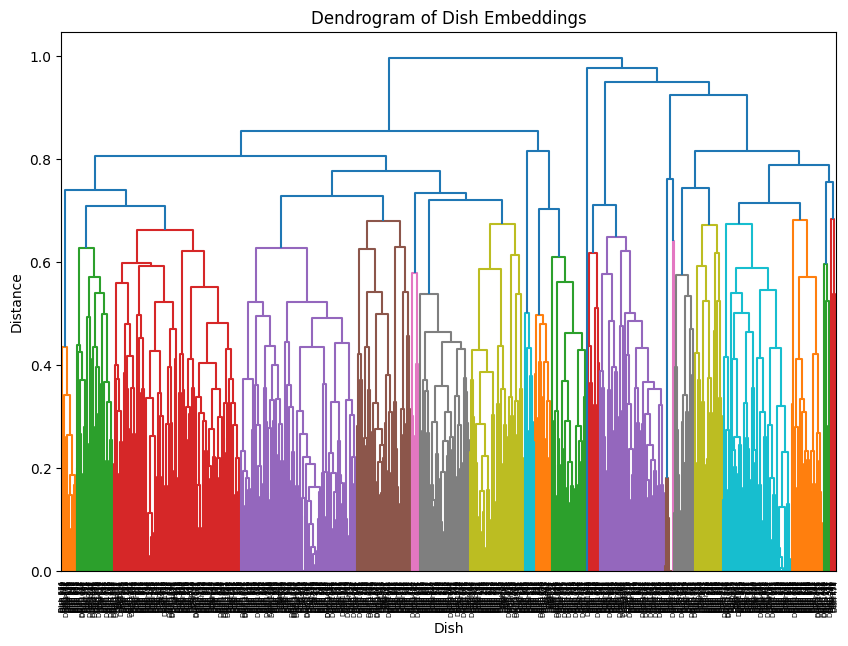

In [132]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Perform hierarchical clustering
linkage_matrix = linkage(embedding_matrix, method='complete', metric="cosine")  # Use 'ward', 'average', or 'complete'

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=[f"Dish {i+1}" for i in range(len(embedding_matrix))])
plt.title("Dendrogram of Dish Embeddings")
plt.xlabel("Dish")
plt.ylabel("Distance")
plt.show()

In [156]:
import plotly.figure_factory as ff

# Create an interactive dendrogram using Plotly
fig = ff.create_dendrogram(
    embedding_matrix, labels=dish_names, linkagefun=lambda x: linkage_matrix
)
fig.update_layout(
    width=20000,
    height=1000,
    title="Interactive Dendrogram of Dish Embeddings",
    xaxis_title="Dishes",
    yaxis_title="Distance"
)

# Show the interactive dendrogram
fig.write_html("dendrogram.html")


In [159]:

max_distance = 0.5  # Set the distance threshold for clusters
clusters = fcluster(linkage_matrix, t=max_distance, criterion='distance')  # Extract flat clusters

# Create a dictionary to store names in each cluster
cluster_dict = {}
for name, cluster_id in zip(dish_names, clusters):
    if cluster_id not in cluster_dict:
        cluster_dict[cluster_id] = []
    cluster_dict[cluster_id].append(name)

# Print 10 random names from each cluster
for cluster_id, cluster_names in cluster_dict.items():
    print(f"Cluster {cluster_id}:")
    random_names = random.sample(cluster_names, min(10, len(cluster_names)))
    for name in random_names:
        print(name)
    print()



Cluster 31:
hähnchengeschnetzeltes kokos curry duftbruchreis
hähnchenbrustfilet natur chinagemüse kokoscurrysauce duftbruchreis
hähnchenbrustfilet natur kokoscurrysauce duftbruchreis chinakohlsalat
hähnchenbrustfilet natur hawai vegane hackbällchen jeweils kokos ingwercurrysauce gemüsecouscous chinakohlsalat
putengeschnetzeltes kokoscurrysoße duftbruchreis chinakohlsalat
hähnchenbrustfilet natur kokoscurrysauce duftbruchreis rohkostsalat
hähnchenbrustfilet natur kokoscurrysauce duftbruchreis

Cluster 35:
seelachs kartoffelpanade hamburger kartoffelsalat endiviensalat
hausgemachter cheddarburger belegt salathausgemachtem dip rindfleisch cheddarkäse zwiebeln tomaten
hausgemachter spicy crunchychickenburger selbstgemachter burgerdip belegt salat mais karottenstreifen
hausgemachter cheeseburger belegt rindfleisch cheddarkäse salat zwiebeln tomaten
hausgemachter spicy crunchychickenburger selbstgemachtem burgerdip karottenstreifen
hamburger gebackenem fischfilet remouladensauce pommes frite

In [175]:
df["hierarchical_cluster"] = clusters

# compute the average dish embedding for each cluster
cluster_centers = []
for cluster_id in range(1, max(clusters) + 1):
    cluster_embeddings = embedding_matrix[clusters == cluster_id]
    cluster_center = np.mean(cluster_embeddings, axis=0)
    cluster_centers.append(cluster_center)

# for every cluster, give me the "meal_clean" of the dish that is closest to its respective cluster center based on cosine similarity
closest_dishes = []
for cluster_id, cluster_center in enumerate(cluster_centers, start=1):
    cosine_similarities = np.dot(embedding_matrix, cluster_center) / (np.linalg.norm(embedding_matrix, axis=1) * np.linalg.norm(cluster_center))
    closest_dish_idx = np.argmax(cosine_similarities)
    closest_dish = df.iloc[closest_dish_idx]["meal_clean"]
    closest_dish_embedding = embedding_matrix[closest_dish_idx]
    closest_dishes.append((closest_dish_idx, closest_dish, cluster_id, closest_dish_embedding))

closest_dishes_df = pd.DataFrame(closest_dishes, columns=["index", "representative_dish", "cluster_label", "dish_embedding"])
closest_dishes_df

,index,representative_dish,cluster_label,dish_embedding
0,578,fleischküchle pfefferrahmsauce kartoffelpüree ...,1,"[0.004235164, 0.038924806, 0.020439861, 0.0021..."
1,1027,schweinegeschnetzeltes zürcher art pilzen kart...,2,"[0.019303547, 0.08479982, 0.034597345, -0.0174..."
2,13,hausgemachter kaiserschmarren rosinen apfelkom...,3,"[0.009703227, 0.063869, 0.016221723, -0.018640..."
3,119,hähnchennuggets teufelsauce reis,4,"[0.046210177, 0.066109695, 0.021196937, 0.0166..."
4,554,schwäbischer sauerbraten kartoffelpüree rotkohl,5,"[0.004760391, 0.03574198, 0.056985173, 0.00660..."
...,...,...,...,...
69,321,cevapcici ajvar djuwetschreis krautsalat,70,"[0.029830696, 0.086826816, 0.017340932, 0.0256..."
70,229,fischfilet müllerin kartoffeln rahmspinat,71,"[0.043616656, 0.027838923, 0.005780695, 0.0081..."
71,40,aktion lammragout provenciale rahmpolenta,72,"[0.03606734, -0.0120379375, 0.009554458, -0.01..."
72,473,hirtenrolle ajvarsoße,73,"[0.037861496, 0.0190114, 0.014958832, -0.00821..."


In [193]:
import random

# write a function where I can assign a weight to three random selected cluster center dishes. 
def select_random_dishes(df, num_dishes=3):
    # Select random dishes from the cluster centers
    selected_dishes = df.sample(n=num_dishes)
    
    return selected_dishes



In [235]:
random_dishes

,index,representative_dish,cluster_label,dish_embedding
66,222,rigatoni al forno speck käse überbacken,67,"[0.03842042, 0.0057314727, -0.005529869, 0.015..."
57,917,kürbiskarotteningwersuppe brötchen,58,"[0.018815923, 0.008753915, 0.013957496, 0.0452..."
21,384,asiatische reispfanne gemüse putenstreifen,22,"[0.061077803, 0.067778066, 0.017766243, 0.0152..."


In [234]:
# Example usage
random_dishes = select_random_dishes(closest_dishes_df)
random_dishes

# now write a function where I can assign weights from 0 to 1 to each of the random dishes
def assign_weights(df, weights):
    
    # Standardize the weights between 0 and 1
    standardized_weights = (weights - weights.min()) / (weights.max() - weights.min())
    
    # Compute the weighted average vector of the dish embeddings
    weighted_embeddings = df["dish_embedding"].apply(lambda x: np.array(x)) * standardized_weights[:, np.newaxis]
    user_vector = np.sum(weighted_embeddings, axis=0) / np.sum(standardized_weights)
    
    return user_vector

